# Exploratory Data Analysis


## 1. Dataset Validation and Overview

Brief validation of the final engineered dataset before conducting exploratory analysis.


### 1.1 Dataset Loading


In [51]:
# ==================================================
# Imports
# ==================================================

from pathlib import Path

import pandas as pd
import numpy as np

# ==================================================
# Project Paths
# ==================================================

PROJECT_ROOT = Path("..")

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "engineered_zillow_fema_data.csv"
)

RESULTS_FIGURES = (
    PROJECT_ROOT
    / "results"
    / "figures"
)

RESULTS_TABLES = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

RESULTS_LOGS = (
    PROJECT_ROOT
    / "results"
    / "logs"
)

# ==================================================
# Project Colors
# ==================================================

PROJECT_COLORS = {

    # Core project palette
    "primary": "#2F4858",      # deep slate blue
    "secondary": "#A5A58D",    # muted sage
    "tertiary": "#6B9080",     # soft green-gray

    # Risk levels
    "risk_low": "#A5A58D",
    "risk_medium": "#6B9080",
    "risk_high": "#2F4858",

    # Maps / choropleths
    "map_outline": "#2B2D42",
    "missing": "#E0E0E0",

    # Reference lines
    "reference": "#7D8597",

    # Model comparison (later)
    "baseline": "#A5A58D",
    "enhanced": "#2F4858",

    # Regression / ML comparison (later)
    "regression": "#6B9080",
    "machine_learning": "#2F4858",

    # SHAP / feature importance (later)
    "positive": "#52796F",
    "negative": "#B56576",

    # Scatterplots
    "scatter": "#7D98A1",

    # Heatmaps
    "heatmap_cmap": "YlOrRd"
}

# ==================================================
# Load Dataset
# ==================================================

df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape}")

Dataset Shape: (11963, 25)


### 1.2 Dataset Validation


In [3]:
# ==================================================
# Dataset Validation
# ==================================================

# convert date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# basic validation checks
num_rows = df.shape[0]
num_columns = df.shape[1]
num_counties = df["RegionName"].nunique()
start_date = df["Date"].min()
end_date = df["Date"].max()

# duplicate county-month rows
duplicate_count = df.duplicated(subset=["RegionID", "Date"]).sum()

print("Rows:", num_rows)
print("Columns:", num_columns)
print("Counties:", num_counties)
print("Start Date:", start_date)
print("End Date:", end_date)
print("Duplicate county-month rows:", duplicate_count)

Rows: 11963
Columns: 25
Counties: 67
Start Date: 2011-01-31 00:00:00
End Date: 2025-12-31 00:00:00
Duplicate county-month rows: 0


In [4]:
# ==================================================
# Missing Value Check
# ==================================================

validation_cols = [
    "HousingPrice",
    "CFLD_RISKS",
    "HRCN_RISKS",
    "POPULATION"
]

print("Missing Values:")
print(df[validation_cols].isnull().sum())

# ==================================================
# Negative Value Check
# ==================================================

numeric_checks = [
    "HousingPrice",
    "POPULATION"
]

print("\nNegative Values:")

for col in numeric_checks:
    negative_count = (df[col] < 0).sum()
    print(f"{col}: {negative_count}")

engineered_cols = [
    "HousingPrice_lag1",
    "HousingPrice_lag12",
    "CFLD_RISKS_x_Time",
    "HRCN_RISKS_x_Time"
]

print(df[engineered_cols].isnull().sum())

Missing Values:
HousingPrice    0
CFLD_RISKS      0
HRCN_RISKS      0
POPULATION      0
dtype: int64

Negative Values:
HousingPrice: 0
POPULATION: 0
HousingPrice_lag1     0
HousingPrice_lag12    0
CFLD_RISKS_x_Time     0
HRCN_RISKS_x_Time     0
dtype: int64


In [5]:
# ==================================================
# Climate Risk Summary
# ==================================================

risk_cols = [
    "CFLD_RISKS",
    "HRCN_RISKS"
]

print(
    df[risk_cols]
    .describe()
    .round(2)
)

       CFLD_RISKS  HRCN_RISKS
count    11963.00    11963.00
mean        47.52       94.02
std         37.72        5.43
min          0.00       74.47
25%          0.00       90.57
50%         61.20       94.99
75%         77.40       98.66
max         99.60       99.96


### 1.3 Dataset Overview


In [6]:
# ==================================================
# Dataset Overview Table
# ==================================================

dataset_overview = pd.DataFrame({
    "Metric": [
        "Observations",
        "Variables",
        "Counties",
        "Start Date",
        "End Date"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df["RegionName"].nunique(),
        df["Date"].min().date(),
        df["Date"].max().date()
    ]
})

# display table
display(dataset_overview)

# save table
dataset_overview.to_csv(
    RESULTS_TABLES / "dataset_overview.csv",
    index=False
)

print(
    f"Saved: "
    f"{RESULTS_TABLES / 'dataset_overview.csv'}"
)

,Metric,Value
0,Observations,11963
1,Variables,25
2,Counties,67
3,Start Date,2011-01-31
4,End Date,2025-12-31


Saved: ..\results\tables\dataset_overview.csv


### 1.4 Summary Statistics


In [7]:
# ==================================================
# Summary Statistics Table
# ==================================================

summary_vars = [
    "HousingPrice",
    "CFLD_RISKS",
    "HRCN_RISKS",
    "POPULATION"
]

summary_statistics = (
    df[summary_vars]
    .describe()
    .T[["mean", "std", "min", "max"]]
    .round(2)
    .reset_index()
    .rename(columns={
        "index": "Variable",
        "mean": "Mean",
        "std": "Std",
        "min": "Min",
        "max": "Max"
    })
)

# display table
display(summary_statistics)

# save table
summary_statistics.to_csv(
    RESULTS_TABLES / "summary_statistics.csv",
    index=False
)

print(
    f"Saved: "
    f"{RESULTS_TABLES / 'summary_statistics.csv'}"
)

,Variable,Mean,Std,Min,Max
0,HousingPrice,215693.70,118638.24,68319.07,1001663.00
1,CFLD_RISKS,47.52,37.72,0.00,99.60
2,HRCN_RISKS,94.02,5.43,74.47,99.96
3,POPULATION,323064.54,498037.71,6344.00,2698679.00


Saved: ..\results\tables\summary_statistics.csv


### Key Takeaways

- The dataset contains substantial variation in housing prices across Florida counties.
- Flood risk exhibits considerable variation, ranging from no exposure to extremely high exposure.
- Hurricane risk is consistently high across most Florida counties, with relatively lower variation.
- Population levels vary significantly across counties, highlighting differences in county size and urbanization.

## 2. Understanding Florida Climate Risk

Explore the spatial distribution of climate risk across Florida counties.


In [8]:
import geopandas as gpd

print(gpd.__version__)

1.1.3


### 2.1 Flood Risk Map


In [9]:
# ==================================================
# Load County Shapefile
# ==================================================

SHAPEFILE_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "shapefiles"
    / "tl_2025_us_county"
    / "tl_2025_us_county.shp"
)

counties_gdf = gpd.read_file(SHAPEFILE_PATH)

print("Shapefile Shape:", counties_gdf.shape)
print(counties_gdf.columns)

# ==================================================
# Filter Shapefile to Florida Counties
# ==================================================

fl_counties_gdf = counties_gdf[counties_gdf["STATEFP"] == "12"].copy()

print("Florida Counties Shape:", fl_counties_gdf.shape)
print("Number of Florida counties:", fl_counties_gdf["GEOID"].nunique())

fl_counties_gdf[["GEOID", "NAME", "NAMELSAD"]].head()

Shapefile Shape: (3235, 19)
Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP',
       'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry'],
      dtype='str')
Florida Counties Shape: (67, 19)
Number of Florida counties: 67


,GEOID,NAME,NAMELSAD
22,12045,Gulf,Gulf County
46,12105,Polk,Polk County
93,12079,Madison,Madison County
173,12029,Dixie,Dixie County
187,12097,Osceola,Osceola County


In [10]:
# ==================================================
# County-Level Climate Risk Dataset
# ==================================================

county_risk_df = (
    df[
        [
            "STCOFIPS",
            "RegionName",
            "CFLD_RISKS",
            "HRCN_RISKS"
        ]
    ]
    .drop_duplicates()
    .copy()
)

# convert county fips to 5-digit string to match shapefile GEOID
county_risk_df["GEOID"] = (
    county_risk_df["STCOFIPS"]
    .astype(str)
    .str.zfill(5)
)

print("County Risk Shape:", county_risk_df.shape)

display(county_risk_df.head())

County Risk Shape: (67, 5)


,STCOFIPS,RegionName,CFLD_RISKS,HRCN_RISKS,GEOID
0,12001,Alachua County,0.0,96.704214,12001
180,12003,Baker County,0.0,74.468085,12003
360,12005,Bay County,77.2,98.664998,12005
540,12007,Bradford County,0.0,87.567793,12007
720,12009,Brevard County,82.0,99.707968,12009


In [11]:
# ==================================================
# Merge Florida County Geometry with Climate Risk Data
# ==================================================

fl_risk_map_gdf = fl_counties_gdf.merge(
    county_risk_df,
    on="GEOID",
    how="left"
)

print("Merged Map Data Shape:", fl_risk_map_gdf.shape)

# check if any counties did not match
missing_risk = fl_risk_map_gdf[
    fl_risk_map_gdf["CFLD_RISKS"].isnull()
    | fl_risk_map_gdf["HRCN_RISKS"].isnull()
]

print("Counties with missing risk data:", missing_risk.shape[0])

display(
    fl_risk_map_gdf[
        ["GEOID", "NAME", "RegionName", "CFLD_RISKS", "HRCN_RISKS"]
    ].head()
)

Merged Map Data Shape: (67, 23)
Counties with missing risk data: 0


,GEOID,NAME,RegionName,CFLD_RISKS,HRCN_RISKS
0,12045,Gulf,Gulf County,61.6,93.408427
1,12105,Polk,Polk County,0.0,98.498123
2,12079,Madison,Madison County,0.0,90.571548
3,12029,Dixie,Dixie County,73.6,87.108886
4,12097,Osceola,Osceola County,0.0,94.159366


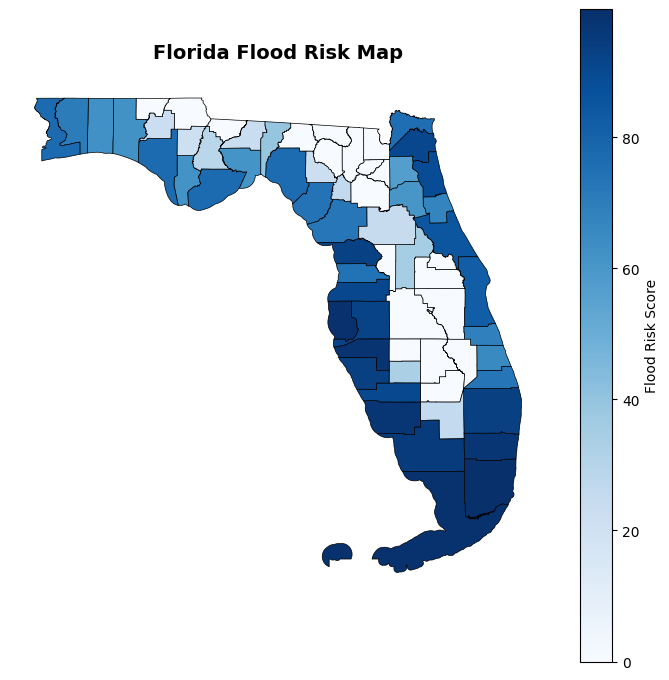

Saved: ..\results\figures\florida_flood_risk_map.png


In [15]:
# ==================================================
# Figure 1: Florida Flood Risk Map
# ==================================================

fig, ax = plt.subplots(figsize=(7, 9))

fl_risk_map_gdf.plot(
    column="CFLD_RISKS",
    cmap="Blues",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "Flood Risk Score",
        "shrink": 0.75
    }
)

ax.set_title(
    "Florida Flood Risk Map",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.axis("off")

plt.tight_layout()

flood_map_path = RESULTS_FIGURES / "florida_flood_risk_map.png"

plt.savefig(
    flood_map_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {flood_map_path}")

### 2.2 Hurricane Risk Map


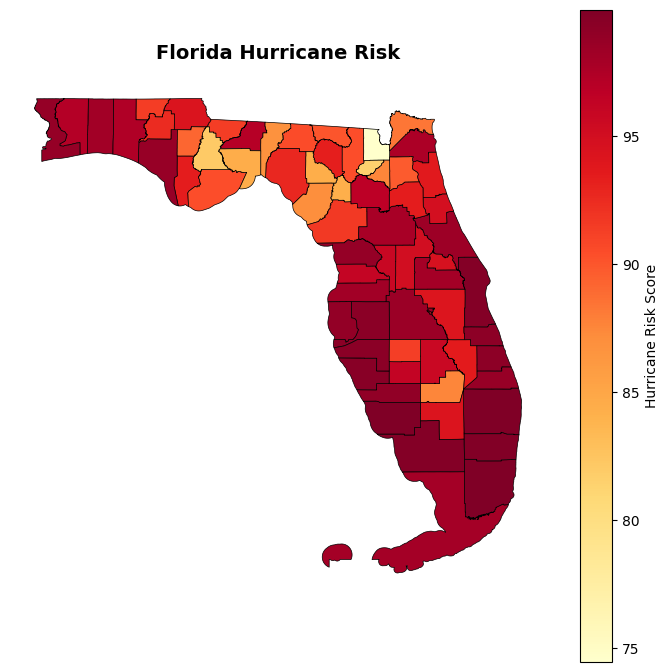

Saved: ..\results\figures\florida_hurricane_risk_map.png


In [22]:
# ==================================================
# Figure 2: Florida Hurricane Risk Map
# ==================================================

fig, ax = plt.subplots(figsize=(7, 9))

fl_risk_map_gdf.plot(
    column="HRCN_RISKS",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "Hurricane Risk Score",
        "shrink": 0.75
    }
)

ax.set_title(
    "Florida Hurricane Risk",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.axis("off")

plt.tight_layout()

hurricane_map_path = (
    RESULTS_FIGURES
    / "florida_hurricane_risk_map.png"
)

plt.savefig(
    hurricane_map_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {hurricane_map_path}")

### Key Observations

- Coastal flood risk exhibits substantial spatial variation across Florida counties.
- Higher flood-risk scores are concentrated in coastal regions, while many inland counties display little to no coastal flood exposure.
- Hurricane risk is consistently high across most Florida counties.
- Compared with flood risk, hurricane risk exhibits considerably less geographic variation.
- The maps suggest that different climate hazards may affect housing markets through different spatial mechanisms.



## 3. Understanding Florida Housing Markets

Examine how housing values evolved across Florida over time.


### 3.1 Florida Housing Price Trends


In [26]:
# ==================================================
# Step 3: Understanding Florida Housing Markets
# Figure 3 Data Preparation
# ==================================================

# make sure date is in datetime format
df["Date"] = pd.to_datetime(df["Date"])

# calculate average housing price across Florida counties for each month
fl_housing_trend = (
    df.groupby("Date", as_index=False)
      .agg(avg_housing_price=("HousingPrice", "mean"))
)

# preview result
print("Housing trend data shape:", fl_housing_trend.shape)
print("Date range:", fl_housing_trend["Date"].min(), "to", fl_housing_trend["Date"].max())

# summary statistics for the statewide trend
fl_housing_trend["avg_housing_price"].describe()

# first and last values
print("Start Price:", round(fl_housing_trend["avg_housing_price"].iloc[0], 2))
print("End Price:", round(fl_housing_trend["avg_housing_price"].iloc[-1], 2))

fl_housing_trend.head()



Housing trend data shape: (180, 2)
Date range: 2011-01-31 00:00:00 to 2025-12-31 00:00:00
Start Price: 129641.71
End Price: 324260.33


,Date,avg_housing_price
0,2011-01-31,129641.713433
1,2011-02-28,128662.031003
2,2011-03-31,127622.415204
3,2011-04-30,126574.683154
4,2011-05-31,125557.938553


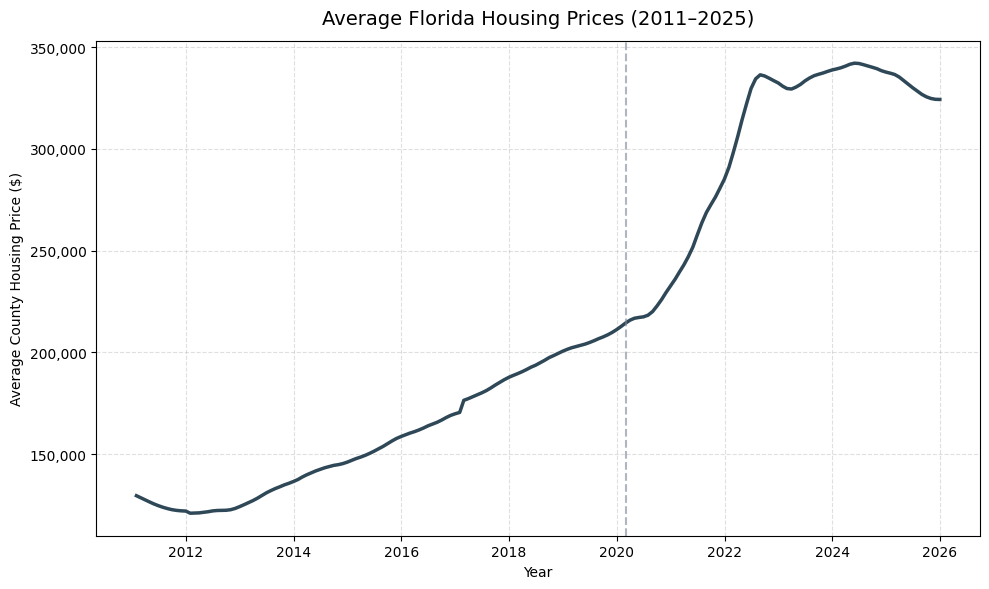

In [39]:
# ==================================================
# Figure 3: Average Florida Housing Prices (2011–2025)
# ==================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    fl_housing_trend["Date"],
    fl_housing_trend["avg_housing_price"],
    linewidth=2.5,
    color=PROJECT_COLORS["primary"]
)

# COVID reference line
ax.axvline(
    pd.Timestamp("2020-03-01"),
    linestyle="--",
    linewidth=1.5,
    alpha=0.6,
    color=PROJECT_COLORS["reference"]
)

ax.set_title(
    "Average Florida Housing Prices (2011–2025)",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Year")
ax.set_ylabel("Average County Housing Price ($)")

ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    RESULTS_FIGURES / "florida_housing_price_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 3.2 Key Observations
- Average housing prices in Florida increased substantially between 2011 and 2025, rising from approximately \$130,000 to over \$320,000.
- Housing prices declined slightly during 2011–2012 before entering a prolonged period of appreciation.
- From 2012 to 2020, Florida housing prices exhibited a steady and sustained upward trend.
- The most rapid increase in housing prices occurred between 2020 and 2022, coinciding with the COVID-19 housing boom.
- Housing prices remained elevated after 2022, although the rate of appreciation slowed relative to the pandemic period.
- A modest moderation in housing prices is visible near the end of the study period, but values remained substantially above pre-pandemic levels.
- The figure suggests that temporal market dynamics play a major role in housing valuation and should be accounted for when assessing the contribution of climate-risk variables.

## 4. Linking Climate Risk and Housing Markets

Explore whether housing market behavior differs across climate-risk levels.


### 4.1 High-Risk vs Low-Risk Trends


In [31]:
# ==================================================
# Figure 4: High vs Low Flood Risk Groups
# Data Preparation
# ==================================================

# county-level flood risk
county_risk = (
    df[["STCOFIPS", "RegionName", "CFLD_RISKS"]]
    .drop_duplicates()
)

# median flood-risk threshold
flood_risk_median = county_risk["CFLD_RISKS"].median()

print("Median Flood Risk:", flood_risk_median)

# create risk groups
county_risk["RiskGroup"] = np.where(
    county_risk["CFLD_RISKS"] >= flood_risk_median,
    "High Flood Risk",
    "Low Flood Risk"
)

# validation
print("\nCounty Counts:")
print(county_risk["RiskGroup"].value_counts())

county_risk.head()

Median Flood Risk: 61.2

County Counts:
RiskGroup
High Flood Risk    34
Low Flood Risk     33
Name: count, dtype: int64


,STCOFIPS,RegionName,CFLD_RISKS,RiskGroup
0,12001,Alachua County,0.0,Low Flood Risk
180,12003,Baker County,0.0,Low Flood Risk
360,12005,Bay County,77.2,High Flood Risk
540,12007,Bradford County,0.0,Low Flood Risk
720,12009,Brevard County,82.0,High Flood Risk


In [32]:
# ==================================================
# Figure 4: High vs Low Flood Risk Housing Trends
# Trend Data Preparation
# ==================================================

# merge risk groups back into the full panel dataset
df_risk_trend = df.merge(
    county_risk[["STCOFIPS", "RiskGroup"]],
    on="STCOFIPS",
    how="left"
)

# calculate monthly average housing price by risk group
risk_housing_trend = (
    df_risk_trend
    .groupby(["Date", "RiskGroup"], as_index=False)
    .agg(avg_housing_price=("HousingPrice", "mean"))
)

# validation
print("Trend data shape:", risk_housing_trend.shape)
print("\nRisk groups:")
print(risk_housing_trend["RiskGroup"].value_counts())

risk_housing_trend.head()

Trend data shape: (360, 3)

Risk groups:
RiskGroup
High Flood Risk    180
Low Flood Risk     180
Name: count, dtype: int64


,Date,RiskGroup,avg_housing_price
0,2011-01-31,High Flood Risk,146895.463698
1,2011-01-31,Low Flood Risk,111274.817989
2,2011-02-28,High Flood Risk,145809.010007
3,2011-02-28,Low Flood Risk,110408.795290
4,2011-03-31,High Flood Risk,144590.912466


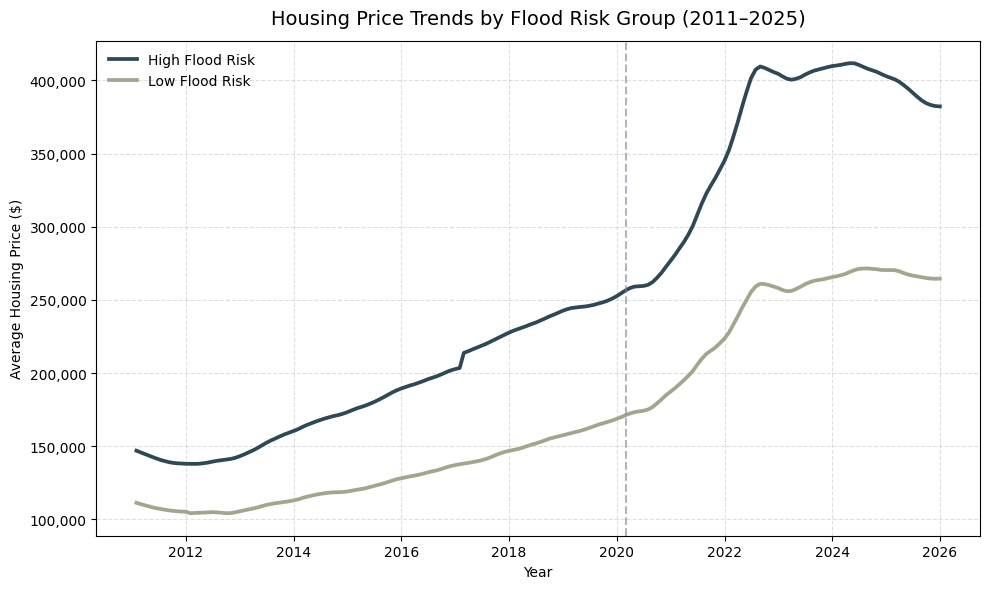

In [38]:
# ==================================================
# Figure 4: High vs Low Flood Risk Housing Trends
# ==================================================

fig, ax = plt.subplots(figsize=(10, 6))

color_map = {
    "High Flood Risk": PROJECT_COLORS["risk_high"],
    "Low Flood Risk": PROJECT_COLORS["risk_low"]
}

for group in ["High Flood Risk", "Low Flood Risk"]:

    subset = risk_housing_trend[
        risk_housing_trend["RiskGroup"] == group
    ]

    ax.plot(
        subset["Date"],
        subset["avg_housing_price"],
        linewidth=2.7,
        label=group,
        color=color_map[group]
    )

ax.axvline(
    pd.Timestamp("2020-03-01"),
    linestyle="--",
    linewidth=1.5,
    alpha=0.6,
    color=PROJECT_COLORS["reference"]
)

ax.set_title(
    "Housing Price Trends by Flood Risk Group (2011–2025)",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Year")
ax.set_ylabel("Average Housing Price ($)")

ax.yaxis.set_major_formatter(
    mtick.StrMethodFormatter('{x:,.0f}')
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.4
)

ax.legend(
    frameon=False
)

plt.tight_layout()

plt.savefig(
    RESULTS_FIGURES / "high_vs_low_flood_risk_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
# ==================================================
# Figure 4 Validation
# Compare Start and End Values
# ==================================================

risk_summary = (
    risk_housing_trend
    .groupby("RiskGroup")
    .agg(
        StartPrice=("avg_housing_price", "first"),
        EndPrice=("avg_housing_price", "last")
    )
)

risk_summary["DollarIncrease"] = (
    risk_summary["EndPrice"]
    - risk_summary["StartPrice"]
)

risk_summary["PercentIncrease"] = (
    risk_summary["DollarIncrease"]
    / risk_summary["StartPrice"]
    * 100
)

risk_summary.round(2)

,StartPrice,EndPrice,DollarIncrease,PercentIncrease
RiskGroup,,,,
High Flood Risk,146895.46,382246.83,235351.36,160.22
Low Flood Risk,111274.82,264516.66,153241.85,137.71


### 4.2 Risk Bucket Analysis (Summary Table)

In [40]:
# ==================================================
# Figure 5: Risk Bucket Analysis
# Create Risk Buckets
# ==================================================

county_risk_bucket = (
    df[["STCOFIPS", "RegionName", "CFLD_RISKS"]]
    .drop_duplicates()
    .copy()
)

county_risk_bucket["RiskBucket"] = pd.qcut(
    county_risk_bucket["CFLD_RISKS"],
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print("County Counts:")
print(county_risk_bucket["RiskBucket"].value_counts())

county_risk_bucket.head()

County Counts:
RiskBucket
Low Risk       23
Medium Risk    22
High Risk      22
Name: count, dtype: int64


,STCOFIPS,RegionName,CFLD_RISKS,RiskBucket
0,12001,Alachua County,0.0,Low Risk
180,12003,Baker County,0.0,Low Risk
360,12005,Bay County,77.2,High Risk
540,12007,Bradford County,0.0,Low Risk
720,12009,Brevard County,82.0,High Risk


In [ ]:
# ==================================================
# Summary Table Preparation
# ==================================================

# merge risk buckets back into panel dataset
df_bucket = df.merge(
    county_risk_bucket[["STCOFIPS", "RiskBucket"]],
    on="STCOFIPS",
    how="left"
)

# monthly average housing price by bucket
bucket_trend = (
    df_bucket
    .groupby(["Date", "RiskBucket"], as_index=False)
    .agg(avg_housing_price=("HousingPrice", "mean"))
)

print("Bucket trend shape:", bucket_trend.shape)

bucket_trend.head()

Bucket trend shape: (540, 3)


,Date,RiskBucket,avg_housing_price
0,2011-01-31,Low Risk,109253.849765
1,2011-01-31,Medium Risk,131567.245864
2,2011-01-31,High Risk,149074.895320
3,2011-02-28,Low Risk,108424.336911
4,2011-02-28,Medium Risk,130604.389786


In [ ]:
# ==================================================
# Risk Bucket Summary Statistics
# ==================================================

bucket_summary = (
    bucket_trend
    .groupby("RiskBucket")
    .agg(
        StartPrice=("avg_housing_price", "first"),
        EndPrice=("avg_housing_price", "last")
    )
)

bucket_summary["DollarIncrease"] = (
    bucket_summary["EndPrice"]
    - bucket_summary["StartPrice"]
)

bucket_summary["PercentIncrease"] = (
    bucket_summary["DollarIncrease"]
    / bucket_summary["StartPrice"]
    * 100
)

# ==================================================
# Save Summary Table
# ==================================================

bucket_summary = bucket_summary.round(2)

bucket_summary.to_csv(
    RESULTS_TABLES / "flood_risk_bucket_housing_summary.csv"
)

bucket_summary

,StartPrice,EndPrice,DollarIncrease,PercentIncrease
RiskBucket,,,,
Low Risk,109253.85,260763.19,151509.34,138.68
Medium Risk,131567.25,318745.94,187178.69,142.27
High Risk,149074.90,396158.09,247083.19,165.74


### 4.3 County Appreciation vs Climate Risk


In [45]:
# ==================================================
# Figure 5: County Appreciation vs Climate Risk
# County-Level Data Preparation
# ==================================================

county_appreciation = (
    df.sort_values(["STCOFIPS", "Date"])
      .groupby(["STCOFIPS", "RegionName"], as_index=False)
      .agg(
          StartPrice=("HousingPrice", "first"),
          EndPrice=("HousingPrice", "last"),
          FloodRisk=("CFLD_RISKS", "first"),
          HurricaneRisk=("HRCN_RISKS", "first")
      )
)

county_appreciation["DollarIncrease"] = (
    county_appreciation["EndPrice"]
    - county_appreciation["StartPrice"]
)

county_appreciation["PercentIncrease"] = (
    county_appreciation["DollarIncrease"]
    / county_appreciation["StartPrice"]
    * 100
)

print("County appreciation shape:", county_appreciation.shape)
print("Number of counties:", county_appreciation["STCOFIPS"].nunique())

county_appreciation.head()

County appreciation shape: (67, 8)
Number of counties: 67


,STCOFIPS,RegionName,StartPrice,EndPrice,FloodRisk,HurricaneRisk,DollarIncrease,PercentIncrease
0,12001,Alachua County,151065.304144,295724.980175,0.0,96.704214,144659.676031,95.759696
1,12003,Baker County,131145.170913,304355.785989,0.0,74.468085,173210.615076,132.075481
2,12005,Bay County,164525.255977,335751.950042,77.2,98.664998,171226.694065,104.073197
3,12007,Bradford County,104394.359137,235444.762594,0.0,87.567793,131050.403457,125.533989
4,12009,Brevard County,122808.989054,335517.406159,82.0,99.707968,212708.417105,173.202645


In [47]:
# ==================================================
# Figure 5 Validation
# Flood Risk vs Housing Appreciation Correlation
# ==================================================

corr = county_appreciation["FloodRisk"].corr(
    county_appreciation["PercentIncrease"]
)

print(f"Correlation: {corr:.3f}")

Correlation: 0.066


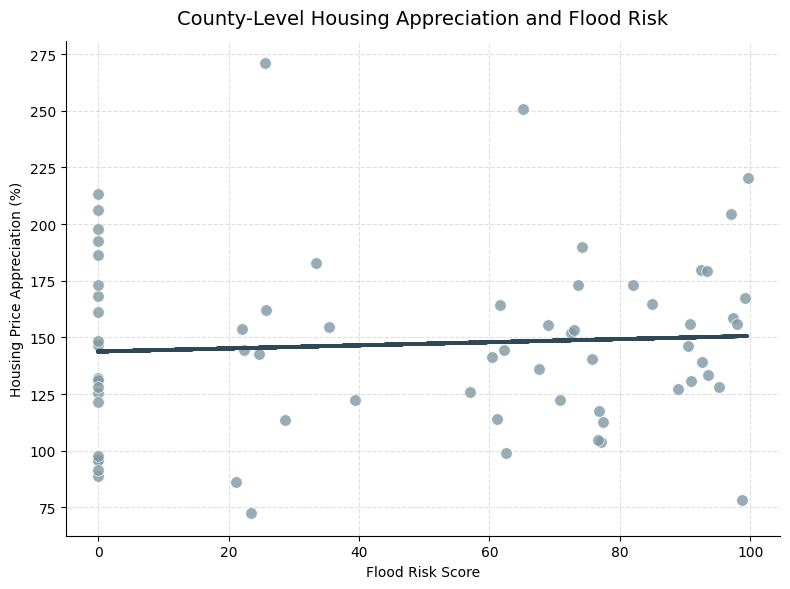

In [52]:
# ==================================================
# Figure 5: "County-Level Housing Appreciation and Flood Risk"
# ==================================================

fig, ax = plt.subplots(figsize=(8, 6))

# scatter points
ax.scatter(
    county_appreciation["FloodRisk"],
    county_appreciation["PercentIncrease"],
    color=PROJECT_COLORS["scatter"],
    alpha=0.8,
    s=70,
    edgecolor="white",
    linewidth=0.6
)

# fitted trend line
z = np.polyfit(
    county_appreciation["FloodRisk"],
    county_appreciation["PercentIncrease"],
    1
)

p = np.poly1d(z)

ax.plot(
    county_appreciation["FloodRisk"],
    p(county_appreciation["FloodRisk"]),
    color=PROJECT_COLORS["primary"],
    linewidth=2.5
)

ax.set_title(
    "County-Level Housing Appreciation and Flood Risk",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Flood Risk Score")
ax.set_ylabel("Housing Price Appreciation (%)")

ax.grid(
    True,
    linestyle="--",
    alpha=0.4
)

# remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    RESULTS_FIGURES / "county_appreciation_vs_flood_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 4.4 Key Observations
- High-flood-risk counties consistently exhibited higher average housing prices than low-flood-risk counties throughout the study period.
- Both risk groups experienced substantial housing-price appreciation between 2011 and 2025.
- High-flood-risk counties appreciated more rapidly than low-flood-risk counties, with average prices increasing by approximately 160% compared with 138% for low-risk counties.
- Risk-bucket analysis revealed a gradual increase in housing-price appreciation as flood-risk levels increased, with high-risk counties exhibiting the strongest growth over the study period.
- Despite these group-level differences, county-level analysis revealed a very weak linear relationship between flood risk and housing-price appreciation (correlation = 0.066).
- The results suggest that while housing-market outcomes differ across climate-risk groups, flood risk alone explains little of the variation in county-level appreciation.
- These findings indicate that housing valuation is influenced by multiple interacting factors and motivate the use of multivariate machine-learning models in later stages of the analysis.


## 5. Exploratory Relationships and Summary Statistics

Investigate relationships among key housing, climate, and demographic variables.


### 5.1 Relationship Heatmap


### 5.2 Key Observations


## 6. Key Findings

Summary of the main findings from the exploratory analysis.
